# 🔧 FASE 1: Preparación de Datos

🔹 Subtarea 1: Importar librerías necesarias

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import kagglehub
import os
from datetime import datetime


Link del reto

https://www.kaggle.com/datasets/shilongzhuang/pizza-sales/data

🔹 Subtarea 2: Cargar dataset desde Kaggle

In [18]:
# 📥 Descargar los archivos más recientes del dataset desde Kaggle
path = kagglehub.dataset_download("shilongzhuang/pizza-sales")
print("Ruta de descarga:", path)

# 📁 Ruta al archivo Excel
excel_path = os.path.join(path, "Data Model - Pizza Sales.xlsx")

# 📄 Leer hojas del archivo
xls = pd.ExcelFile(excel_path)
print("Hojas disponibles:", xls.sheet_names)

# 🧾 Cargar hoja de datos
df = pd.read_excel(xls, sheet_name="pizza_sales")
df.head()


Ruta de descarga: C:\Users\Dell\.cache\kagglehub\datasets\shilongzhuang\pizza-sales\versions\2
Hojas disponibles: ['pizza_sales']


,order_details_id,order_id,pizza_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,2015-01-01,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


🔹 Subtarea 3: Alternativa offline (comentada)

In [19]:
# local_path = r"C:\americo\ia_dema\z-ejercicios_kaggle\Pizza_Restaurant_Sales\data_real\Data Model - Pizza Sales.xlsx"
# xls = pd.ExcelFile(local_path)
# df = pd.read_excel(xls, sheet_name="pizza_sales")


🔹 Subtarea 4: Ver estructura y valores faltantes

In [20]:
print("Dimensiones (filas, columnas):", df.shape)
df.info()

print("\nValores nulos por columna:")
print(df.isnull().sum())

Dimensiones (filas, columnas): (48620, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   order_details_id   48620 non-null  int64         
 1   order_id           48620 non-null  int64         
 2   pizza_id           48620 non-null  object        
 3   quantity           48620 non-null  int64         
 4   order_date         48620 non-null  datetime64[ns]
 5   order_time         48620 non-null  object        
 6   unit_price         48620 non-null  float64       
 7   total_price        48620 non-null  float64       
 8   pizza_size         48620 non-null  object        
 9   pizza_category     48620 non-null  object        
 10  pizza_ingredients  48620 non-null  object        
 11  pizza_name         48620 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(6)
memory usage: 4.5+ 

🔹 Subtarea 5: Limpieza y transformación de variables de tiempo

In [21]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["order_time"] = pd.to_datetime(df["order_time"], format="%H:%M:%S").dt.time
df["día_semana"] = df["order_date"].dt.day_name(locale="es_ES")
df["hora"] = pd.to_datetime(df["order_time"].astype(str)).dt.hour


C:\Users\Dell\AppData\Local\Temp\ipykernel_12204\1339843162.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["hora"] = pd.to_datetime(df["order_time"].astype(str)).dt.hour


# 📊 FASE 2: Análisis Exploratorio de Datos (EDA)

🔹 Subtarea 1: Ver volumen de pedidos por hora

hora
9        1
10       8
11    1231
12    2520
13    2455
14    1472
15    1468
16    1920
17    2336
18    2399
19    2009
20    1642
21    1198
22     663
23      28
Name: order_id, dtype: int64


C:\Users\Dell\AppData\Local\Temp\ipykernel_12204\1198023379.py:12: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Dell\Documents\Angel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


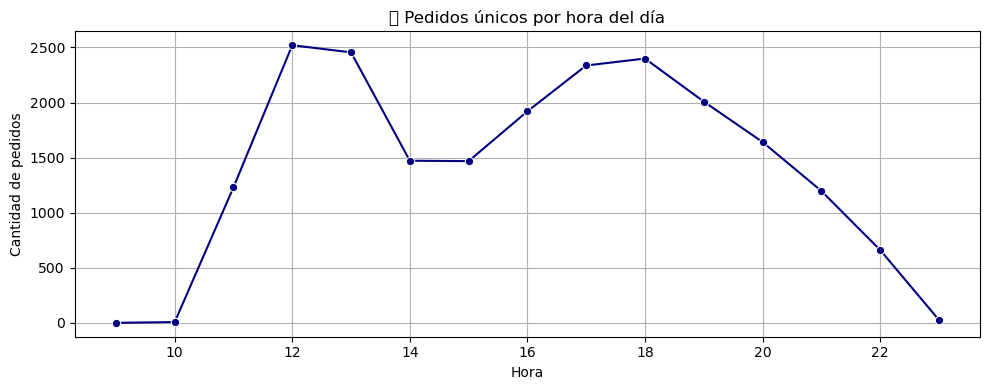

C:\Users\Dell\AppData\Local\Temp\ipykernel_12204\1198023379.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pedidos_por_hora.index, y=pedidos_por_hora.values, palette="rocket")
C:\Users\Dell\AppData\Local\Temp\ipykernel_12204\1198023379.py:21: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Dell\Documents\Angel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


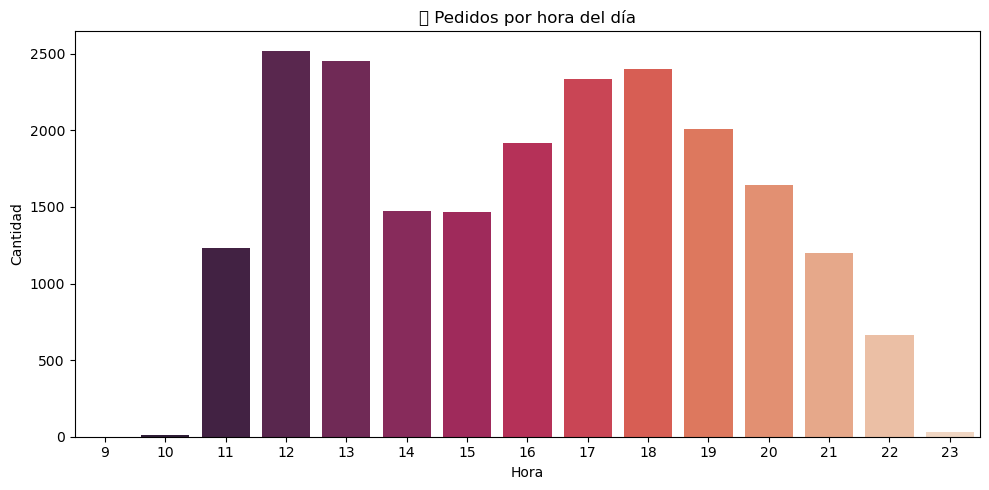

In [27]:
# Tabla de volumen de pedidos
pedidos_por_hora = df.groupby("hora")["order_id"].nunique().sort_index()
print(pedidos_por_hora)

# Gráfico de líneas (cambios por hora)
plt.figure(figsize=(10,4))
sns.lineplot(x=pedidos_por_hora.index, y=pedidos_por_hora.values, marker="o", color="navy")
plt.title("📈 Pedidos únicos por hora del día")
plt.xlabel("Hora")
plt.ylabel("Cantidad de pedidos")
plt.grid(True)
plt.tight_layout()
plt.show()

# Alternativa: gráfico de barras
plt.figure(figsize=(10,5))
sns.barplot(x=pedidos_por_hora.index, y=pedidos_por_hora.values, palette="rocket")
plt.title("📦 Pedidos por hora del día")
plt.xlabel("Hora")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()



🔹 Subtarea 2: Pizzas vendidas por hora en horarios pico

C:\Users\Dell\AppData\Local\Temp\ipykernel_12204\1351245761.py:14: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Dell\Documents\Angel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


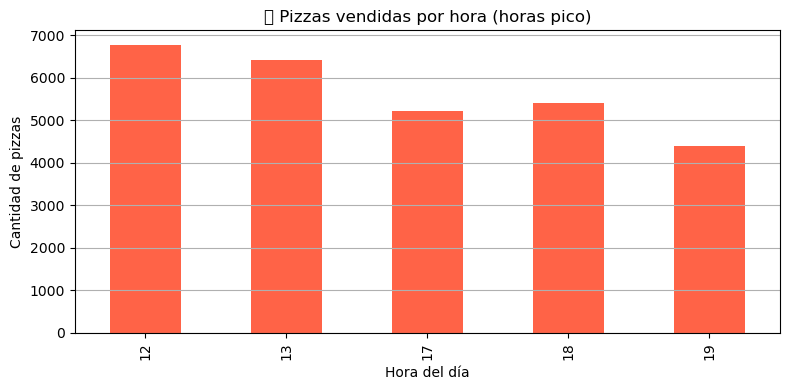

In [28]:
ventas_por_hora_pico = (
    df[df["hora"].isin([12, 13, 17, 18, 19])]
    .groupby("hora")["quantity"]
    .sum()
    .sort_index()
)

# Gráfico de barras
ventas_por_hora_pico.plot(kind="bar", color="tomato", figsize=(8,4))
plt.title("🔥 Pizzas vendidas por hora (horas pico)")
plt.xlabel("Hora del día")
plt.ylabel("Cantidad de pizzas")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


🔹 Subtarea 3: Ver cantidad de pizzas por hora pico

C:\Users\Dell\AppData\Local\Temp\ipykernel_12204\3583765039.py:8: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Dell\Documents\Angel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


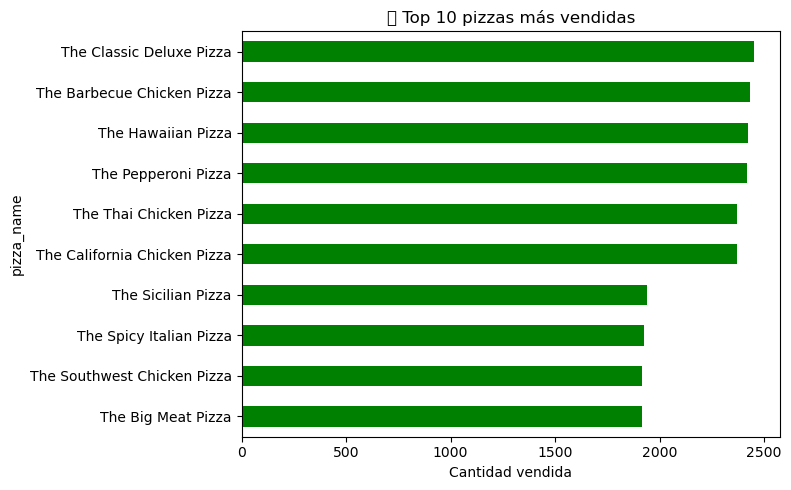

C:\Users\Dell\AppData\Local\Temp\ipykernel_12204\3583765039.py:16: UserWarning: Glyph 128683 (\N{NO ENTRY SIGN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Dell\Documents\Angel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128683 (\N{NO ENTRY SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


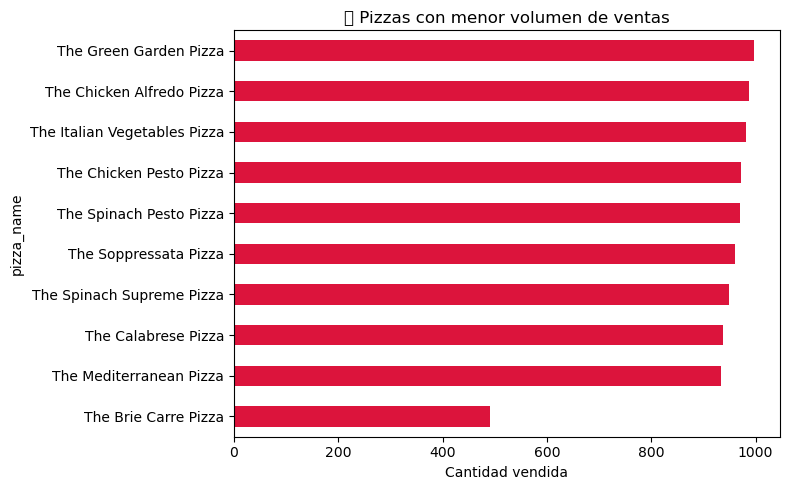

In [29]:
ventas_pizza = df.groupby("pizza_name")["quantity"].sum().sort_values(ascending=False)

# Top 10
ventas_pizza.head(10).plot(kind="barh", color="green", figsize=(8,5))
plt.title("🥇 Top 10 pizzas más vendidas")
plt.xlabel("Cantidad vendida")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Bottom 10
ventas_pizza.tail(10).plot(kind="barh", color="crimson", figsize=(8,5))
plt.title("🚫 Pizzas con menor volumen de ventas")
plt.xlabel("Cantidad vendida")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


🔹 Subtarea 4: Obtener pizzas más y menos vendidas

C:\Users\Dell\AppData\Local\Temp\ipykernel_12204\3870219293.py:9: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Dell\Documents\Angel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


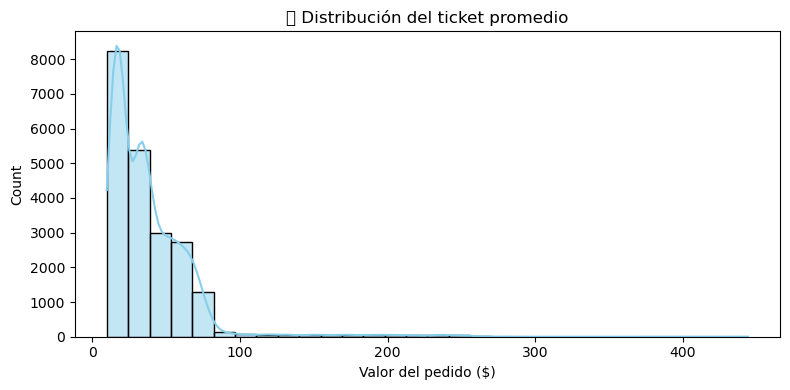

C:\Users\Dell\AppData\Local\Temp\ipykernel_12204\3870219293.py:17: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Dell\Documents\Angel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


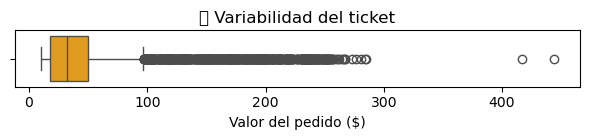

In [30]:
# Crear tabla de ticket
ticket = df.groupby("order_id")["total_price"].sum().reset_index(name="ticket_total")

# Histograma
plt.figure(figsize=(8,4))
sns.histplot(ticket["ticket_total"], bins=30, kde=True, color="skyblue")
plt.title("📊 Distribución del ticket promedio")
plt.xlabel("Valor del pedido ($)")
plt.tight_layout()
plt.show()

# Boxplot para ver outliers
plt.figure(figsize=(6,1.5))
sns.boxplot(x=ticket["ticket_total"], color="orange")
plt.title("🎯 Variabilidad del ticket")
plt.xlabel("Valor del pedido ($)")
plt.tight_layout()
plt.show()


C:\Users\Dell\AppData\Local\Temp\ipykernel_12204\807068157.py:12: UserWarning: Glyph 129383 (\N{PIE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Dell\Documents\Angel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129383 (\N{PIE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


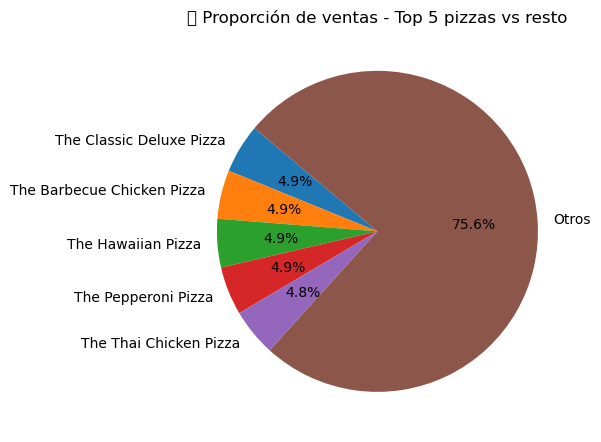

In [33]:
# Top 5 pizzas más vendidas
top5 = ventas_pizza.head(5)
otros = ventas_pizza.iloc[5:].sum()

# Corregido: concatenar Series con pd.concat
pie_data = pd.concat([top5, pd.Series({"Otros": otros})])

# Gráfico de pastel (pie chart)
plt.figure(figsize=(6,6))
plt.pie(pie_data, labels=pie_data.index, autopct="%1.1f%%", startangle=140)
plt.title("🥧 Proporción de ventas - Top 5 pizzas vs resto")
plt.tight_layout()
plt.show()


🔹 Subtarea 5: Calcular valor promedio del pedido (ticket medio)

C:\Users\Dell\AppData\Local\Temp\ipykernel_12204\3529451.py:22: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Dell\Documents\Angel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


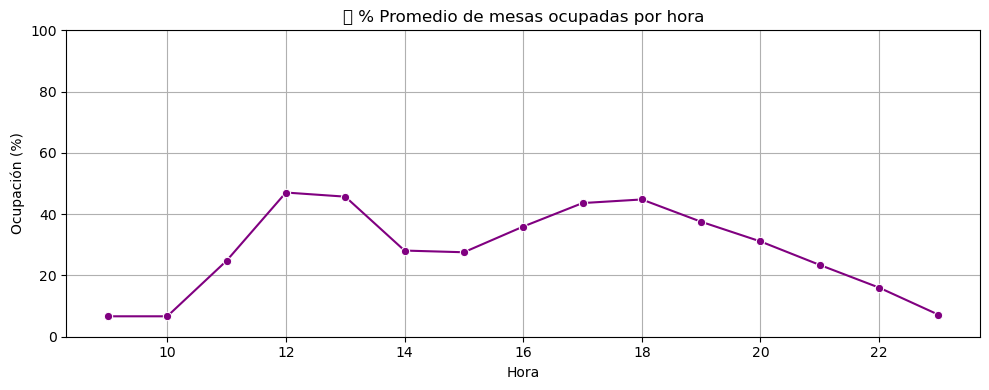

In [31]:
mesas_hora = (
    df.groupby(["order_date", "hora"])["order_id"]
    .nunique()
    .reset_index(name="mesas_ocupadas")
)
mesas_hora["pct_ocupacion"] = mesas_hora["mesas_ocupadas"] / 15 * 100

uso_por_hora = (
    mesas_hora.groupby("hora")["pct_ocupacion"]
    .mean()
    .reset_index()
)

# Gráfico de línea
plt.figure(figsize=(10,4))
sns.lineplot(data=uso_por_hora, x="hora", y="pct_ocupacion", marker="o", color="purple")
plt.title("📈 % Promedio de mesas ocupadas por hora")
plt.xlabel("Hora")
plt.ylabel("Ocupación (%)")
plt.ylim(0, 100)
plt.grid(True)
plt.tight_layout()
plt.show()


🔹 Subtarea 6: Analizar uso del restaurante (mesas ocupadas)

C:\Users\Dell\AppData\Local\Temp\ipykernel_12204\1137810274.py:14: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Dell\Documents\Angel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


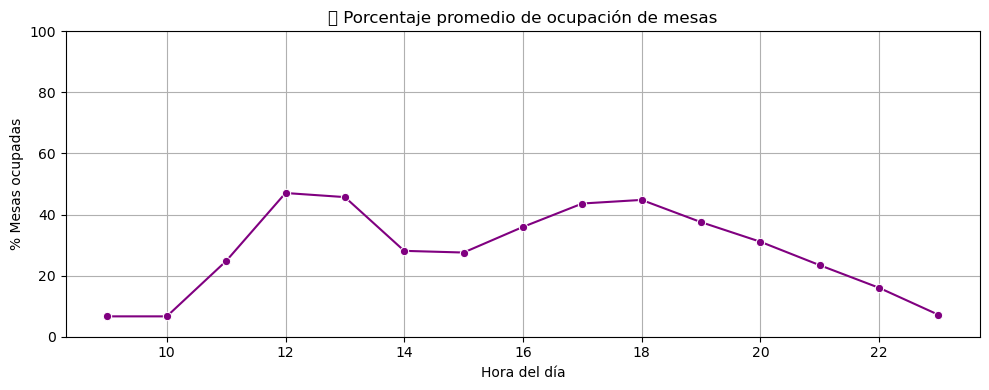

In [26]:
mesas_hora = df.groupby(["order_date", "hora"])["order_id"].nunique().reset_index(name="mesas_ocupadas")
mesas_hora["pct_ocupacion"] = (mesas_hora["mesas_ocupadas"] / 15) * 100

uso_promedio = mesas_hora.groupby("hora")["pct_ocupacion"].mean().reset_index()

# Visualización:
plt.figure(figsize=(10,4))
sns.lineplot(x="hora", y="pct_ocupacion", data=uso_promedio, marker="o", color="purple")
plt.title("📈 Porcentaje promedio de ocupación de mesas")
plt.ylabel("% Mesas ocupadas")
plt.xlabel("Hora del día")
plt.ylim(0, 100)
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\Dell\AppData\Local\Temp\ipykernel_12204\3014283073.py:14: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Dell\Documents\Angel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


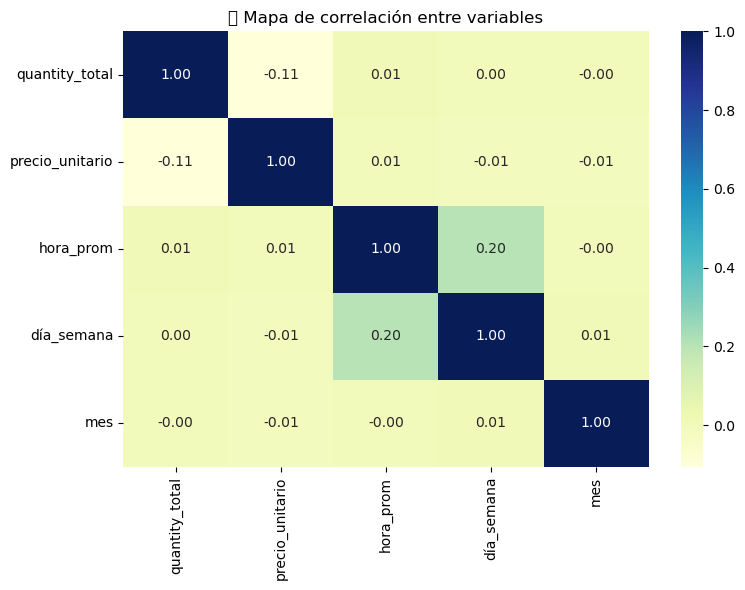

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos solo columnas numéricas relevantes
corr_cols = df_pizza[["quantity_total", "precio_unitario", "hora_prom", "día_semana", "mes"]]

# Calculamos la matriz de correlación
corr_matrix = corr_cols.corr()

# Gráfico heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("🔍 Mapa de correlación entre variables")
plt.tight_layout()
plt.show()


# 📈 FASE 3: Modelos de Regresión — Predicción de Ventas

🎯 Objetivo

Usar regresión para predecir la cantidad de pizzas vendidas o el 

valor total del pedido, basándonos en variables relevantes del restaurante.

🔹 Subtarea 1: Definir el objetivo del modelo

Podemos enfocarnos en predecir:

    | Variable objetivo (y)	| ¿Para qué sirve? 📊 | 
    -----------------------------------------------
    | quantity	        |  Predecir cuántas pizzas se venderán según día, hora, tipo, etc.
    | total_price	        |  Estimar ingreso de cada pedido u hora
    | Promedio por hora/día	|  Predecir demanda futura para preparar personal/stock


🔍 Dado el contexto del reto, vamos a modelar la venta total de pizzas por hora (total_pizzas) como variable dependiente.

🔹 Subtarea 2: Preparar los datos de entrenamiento

Creamos una tabla con columnas agregadas por día y hora.

In [34]:
# Agrupar por fecha y hora: total de pizzas vendidas por hora
df_reg = (
    df.groupby(["order_date", "hora"])
      .agg(total_pizzas=("quantity", "sum"),
           pedidos=("order_id", "nunique"))
      .reset_index()
)

# Extraer variables del tiempo
df_reg["día_semana"] = df_reg["order_date"].dt.dayofweek     # 0=Lunes
df_reg["mes"] = df_reg["order_date"].dt.month


🔹 Subtarea 3: Seleccionar variables predictoras

        Variables candidatas para el modelo:

        📆 Día de la semana (día_semana)

        🕒 Hora del día (hora)

        📅 Mes (mes)

        🧾 Cantidad de pedidos registrados (pedidos)

In [35]:
X = df_reg[["hora", "día_semana", "mes", "pedidos"]]
y = df_reg["total_pizzas"]


🔹 Subtarea 4: Crear y evaluar el modelo de regresión

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Predecir y evaluar
y_pred = modelo.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"📉 MAE (error medio absoluto): {mae:.2f}")
print(f"📈 R² (coef. de determinación): {r2:.2f}")


📉 MAE (error medio absoluto): 2.84
📈 R² (coef. de determinación): 0.73


🔹 Subtarea 5: Interpretar resultados y aplicar

In [37]:
# Coeficientes del modelo
coef = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo.coef_
}).sort_values(by="Coeficiente", key=abs, ascending=False)

print("📊 Importancia de variables predictoras:")
print(coef)


📊 Importancia de variables predictoras:
     Variable  Coeficiente
3     pedidos     2.347836
0        hora    -0.191463
1  día_semana     0.013923
2         mes     0.012806


📈 FASE 3 (parte 2): Regresión por tipo de pizza

        🎯 Objetivo alternativo:

        Predecir la cantidad total vendida de cada tipo de pizza a lo largo del tiempo, 

        utilizando variables como día de la semana, tamaño, precio o incluso 

        la hora. Esto puede servir para:

        Estimar demanda futura de cada tipo de pizza 🍕

        Optimizar stock de ingredientes por día/hora

        Planificar producción con mayor precisión

🔹 Subtarea 1: Construcción de dataset agregado por pizza y día

In [40]:
# Agrupar por fecha y tipo de pizza
# Convertimos 'order_time' a datetime antes de agrupar para evitar el warning
df["hora"] = pd.to_datetime(df["order_time"].astype(str), format="%H:%M:%S").dt.hour

# Agrupar por fecha y pizza
df_pizza = (
    df.groupby(["order_date", "pizza_name"])
      .agg(
          quantity_total=("quantity", "sum"),
          precio_unitario=("unit_price", "mean"),
          hora_prom=("hora", "mean")  # Usamos la columna 'hora' ya procesada
      )
      .reset_index()
)

# Añadir variables temporales
df_pizza["día_semana"] = df_pizza["order_date"].dt.dayofweek
df_pizza["mes"] = df_pizza["order_date"].dt.month


🔹 Subtarea 2: Seleccionar variables

In [41]:
X2 = df_pizza[["hora_prom", "día_semana", "mes", "precio_unitario"]]
y2 = df_pizza["quantity_total"]


🔹 Subtarea 3: Entrenamiento y evaluación del modelo

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.25, random_state=0)

modelo2 = LinearRegression()
modelo2.fit(X2_train, y2_train)

y2_pred = modelo2.predict(X2_test)

mse = mean_squared_error(y2_test, y2_pred)
r2 = r2_score(y2_test, y2_pred)

print(f"📉 MSE (error cuadrático medio): {mse:.2f}")
print(f"📈 R² del modelo: {r2:.2f}")


📉 MSE (error cuadrático medio): 6.52
📈 R² del modelo: 0.02


🔹 Subtarea 4: Variables más influyentes

In [43]:
pd.DataFrame({
    "Variable": X2.columns,
    "Coeficiente": modelo2.coef_
}).sort_values(by="Coeficiente", key=abs, ascending=False)


,Variable,Coeficiente
3,precio_unitario,-0.093545
0,hora_prom,0.019322
1,día_semana,-0.010033
2,mes,-0.005720


📐 1. Gráfico de comparación: valores reales vs. predichos

    Este gráfico nos permite visualizar el desempeño del modelo lineal que ya entrenamos:

C:\Users\Dell\AppData\Local\Temp\ipykernel_12204\1082513468.py:10: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Dell\AppData\Local\Temp\ipykernel_12204\1082513468.py:10: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Dell\Documents\Angel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Dell\Documents\Angel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


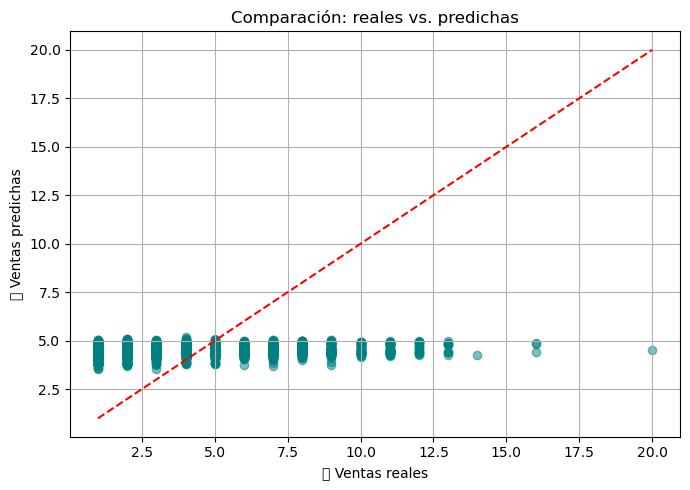

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(y2_test, y2_pred, alpha=0.5, color='teal')
plt.plot([y2_test.min(), y2_test.max()], [y2_test.min(), y2_test.max()], 'r--')
plt.xlabel("📌 Ventas reales")
plt.ylabel("🔮 Ventas predichas")
plt.title("Comparación: reales vs. predichas")
plt.grid(True)
plt.tight_layout()
plt.show()


📌 Gráfico: Ventas Reales vs. Ventas Predichas (modelo lineal)
📷 Descripción rápida:

Cada punto teal representa un par de valores: lo que realmente se vendió vs. lo que el modelo lineal predijo.

La línea roja discontinua es la línea ideal 𝑦 = 𝑥 → donde predicción y realidad son iguales.

Si el modelo fuera perfecto, ¡todos los puntos estarían alineados sobre esa línea!

🔍 Observaciones clave
📉 Dispersión amplia: La mayoría de los puntos no se alinean bien con la línea roja. Están muy dispersos, incluso lejos del trazo ideal.

🎯 Tendencia a subestimar y sobreestimar: Hay muchas predicciones que están muy por debajo o por encima del valor real, especialmente en los extremos.

💡 Esto sugiere que el modelo lineal simple no está capturando bien las complejidades de la demanda según el tipo de pizza, hora, día, etc.

🧠 Interpretación práctica
Este gráfico confirma visualmente lo que los números nos dicen: 👉 El modelo de regresión lineal no es suficiente por sí solo para predecir bien la cantidad vendida de cada pizza.

Ya que tú decidiste activar el combo completo, ¡vamos a comparar ahora con los resultados de Random Forest y Regresión Polinómica para ver cómo se comportan visualmente! 🌲📈

¿Generamos también los gráficos de comparación para esos dos modelos y los enfrentamos cara a cara? 🔥📊 Puedo armar un "plato triple" con visualizaciones, métricas y tabla comparativa. ¿Lo sirvo? 😄

🌳 2. Regresión con Random Forest (modelo no lineal)

Potente para capturar relaciones más complejas

In [45]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

rf = RandomForestRegressor(n_estimators=100, random_state=0)
rf.fit(X2_train, y2_train)

y2_rf = rf.predict(X2_test)

mse_rf = mean_squared_error(y2_test, y2_rf)
r2_rf = r2_score(y2_test, y2_rf)

print(f"🌲 Random Forest - MSE: {mse_rf:.2f} | R²: {r2_rf:.2f}")

🌲 Random Forest - MSE: 3.49 | R²: 0.47


📉 3. Regresión Polinómica (relaciones no lineales suaves)

Vamos a agregar términos cuadráticos para capturar curvaturas en los datos:

In [46]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Transformación de grado 2
poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_model.fit(X2_train, y2_train)

y2_poly = poly_model.predict(X2_test)

mse_poly = mean_squared_error(y2_test, y2_poly)
r2_poly = r2_score(y2_test, y2_poly)

print(f"📈 Regresión Polinómica - MSE: {mse_poly:.2f} | R²: {r2_poly:.2f}")


📈 Regresión Polinómica - MSE: 5.55 | R²: 0.16


📊 Comparativa rápida de resultados

In [48]:
model_scores = pd.DataFrame({
    "Modelo": ["Lineal", "Random Forest", "Polinómica"],
    "R²": [r2, r2_rf, r2_poly],
    "MSE": [mse, mse_rf, mse_poly]
})
print(model_scores.sort_values("R²", ascending=False))

          Modelo        R²       MSE
1  Random Forest  0.472502  3.492389
2     Polinómica  0.161682  5.550226
0         Lineal  0.015796  6.516085


📐 2. Gráfico de comparación: Random Forest

C:\Users\Dell\AppData\Local\Temp\ipykernel_12204\283993607.py:8: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Dell\AppData\Local\Temp\ipykernel_12204\283993607.py:8: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Dell\Documents\Angel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Dell\Documents\Angel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


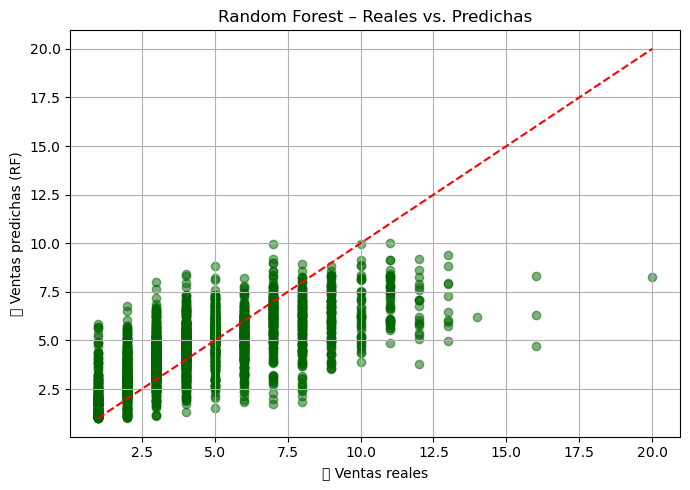

In [50]:
plt.figure(figsize=(7,5))
plt.scatter(y2_test, y2_rf, alpha=0.5, color='darkgreen')
plt.plot([y2_test.min(), y2_test.max()], [y2_test.min(), y2_test.max()], 'r--')
plt.xlabel("📌 Ventas reales")
plt.ylabel("🌲 Ventas predichas (RF)")
plt.title("Random Forest – Reales vs. Predichas")
plt.grid(True)
plt.tight_layout()
plt.show()


📐 3. Gráfico de comparación: Regresión Polinómica

C:\Users\Dell\AppData\Local\Temp\ipykernel_12204\3245833171.py:8: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Dell\AppData\Local\Temp\ipykernel_12204\3245833171.py:8: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Dell\Documents\Angel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


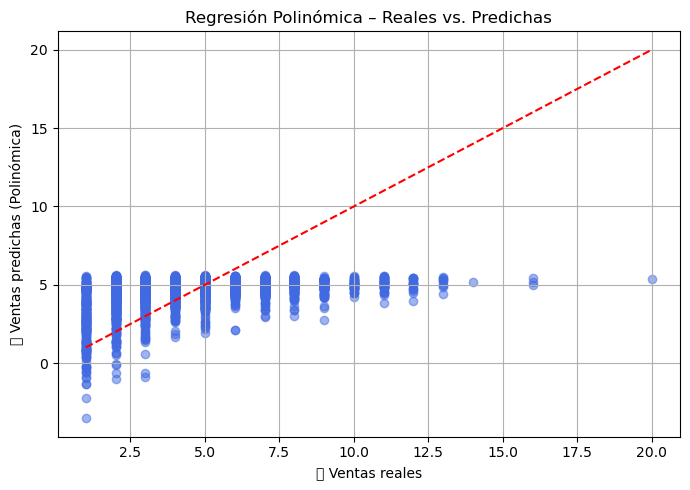

In [51]:
plt.figure(figsize=(7,5))
plt.scatter(y2_test, y2_poly, alpha=0.5, color='royalblue')
plt.plot([y2_test.min(), y2_test.max()], [y2_test.min(), y2_test.max()], 'r--')
plt.xlabel("📌 Ventas reales")
plt.ylabel("🔵 Ventas predichas (Polinómica)")
plt.title("Regresión Polinómica – Reales vs. Predichas")
plt.grid(True)
plt.tight_layout()
plt.show()


🔗 4. Diagrama de correlación

C:\Users\Dell\AppData\Local\Temp\ipykernel_12204\1010094787.py:7: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Dell\Documents\Angel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


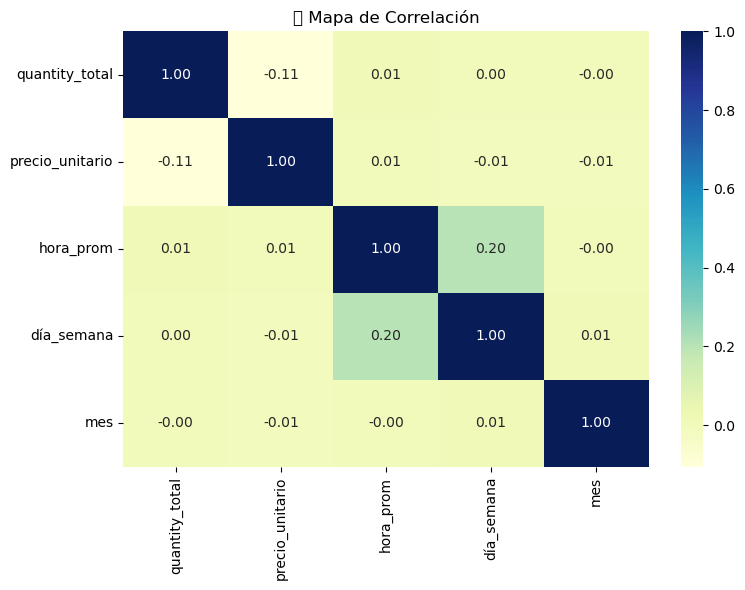

In [52]:
corr_data = df_pizza[["quantity_total", "precio_unitario", "hora_prom", "día_semana", "mes"]]
corr_matrix = corr_data.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("🔗 Mapa de Correlación")
plt.tight_layout()
plt.show()


🔍 5. Diagrama de pares (pairplot)

C:\Users\Dell\AppData\Local\Temp\ipykernel_12204\2693919464.py:3: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Dell\Documents\Angel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


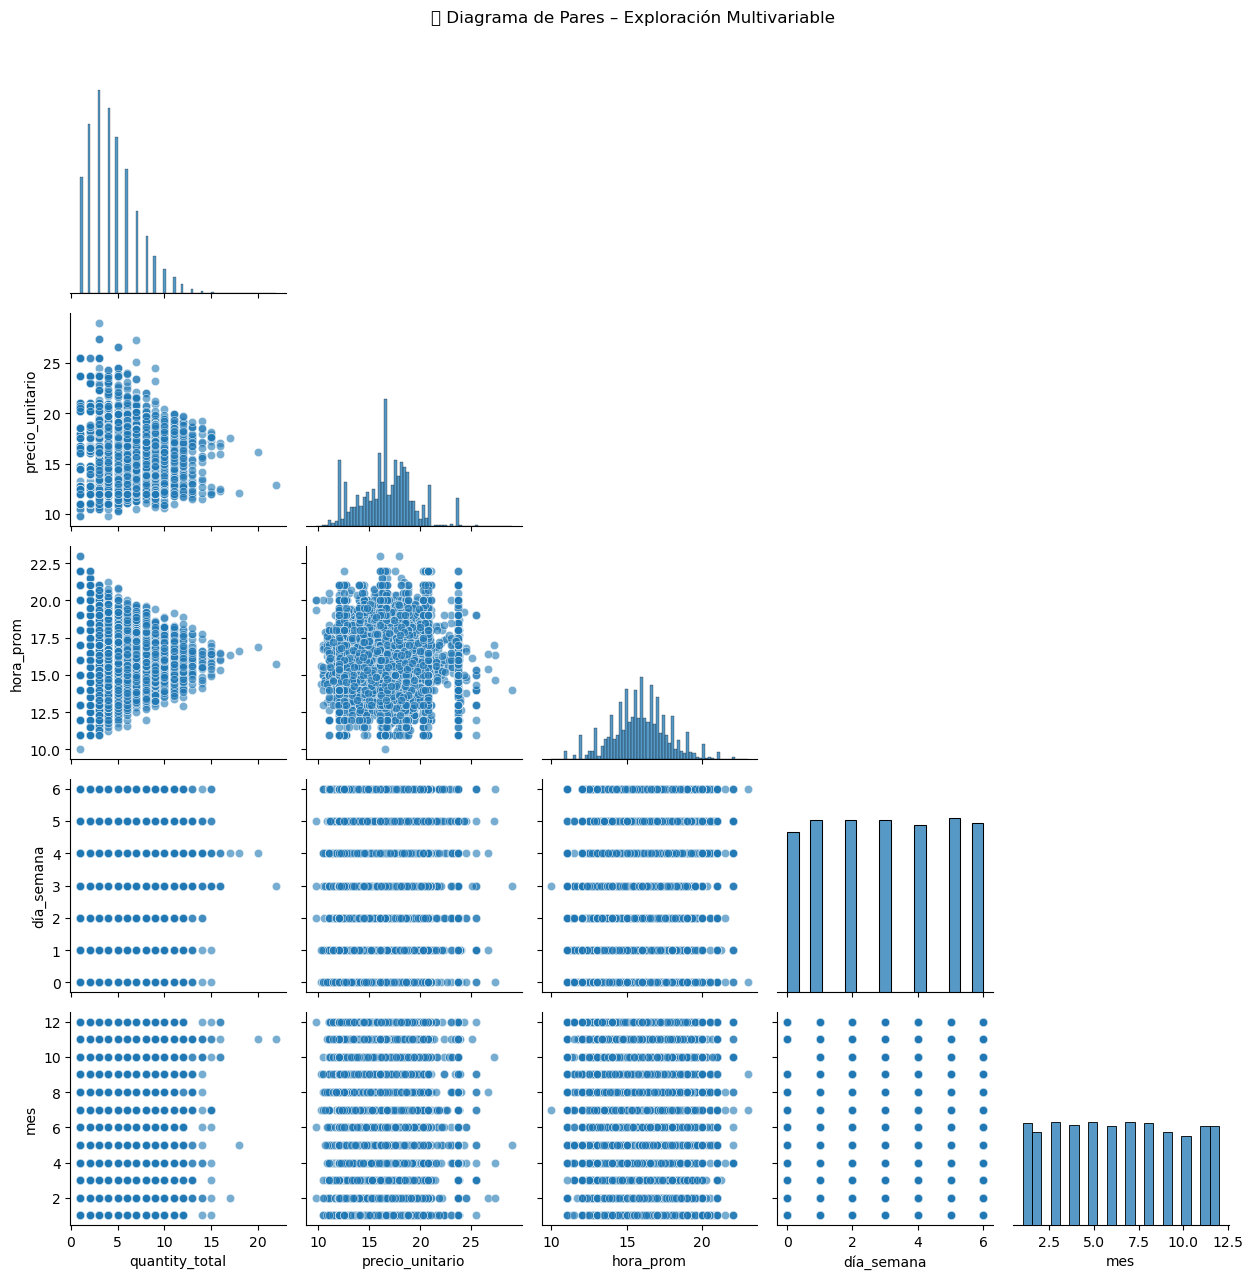

In [53]:
sns.pairplot(corr_data, corner=True, plot_kws={"alpha": 0.6})
plt.suptitle("📉 Diagrama de Pares – Exploración Multivariable", y=1.02)
plt.tight_layout()
plt.show()


🌳 6. Árbol de Decisión

In [54]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

X_tree = df_pizza[["hora_prom", "día_semana", "mes", "precio_unitario"]]
y_tree = df_pizza["quantity_total"]

X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(X_tree, y_tree, test_size=0.2, random_state=42)

tree_model = DecisionTreeRegressor(max_depth=4, random_state=42)
tree_model.fit(X_train_tree, y_train_tree)

y_pred_tree = tree_model.predict(X_test_tree)
r2_tree = r2_score(y_test_tree, y_pred_tree)
mae_tree = mean_squared_error(y_test_tree, y_pred_tree, squared=False)

print(f"🌳 Árbol de Decisión - R²: {r2_tree:.2f} | RMSE: {mae_tree:.2f}")


🌳 Árbol de Decisión - R²: 0.20 | RMSE: 2.23


c:\Users\Dell\Documents\Angel\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


🌿 Visualización del Árbol

c:\Users\Dell\Documents\Angel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


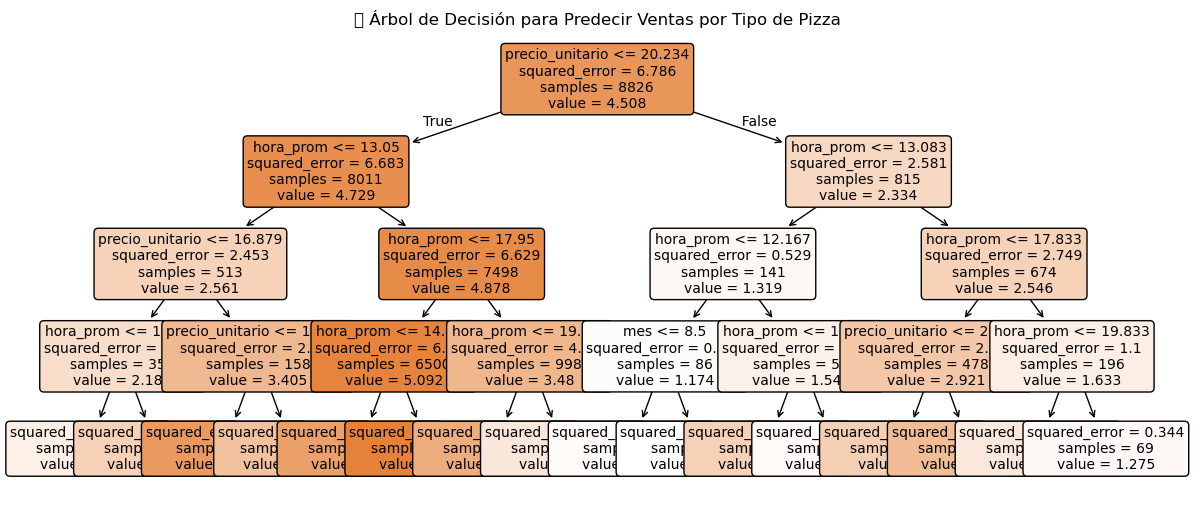

In [55]:
plt.figure(figsize=(14,6))
plot_tree(tree_model, feature_names=X_tree.columns, filled=True, rounded=True, fontsize=10)
plt.title("🌿 Árbol de Decisión para Predecir Ventas por Tipo de Pizza")
plt.show()


# 💡 FASE 4: Ideas Extra – Exploración Avanzada

🔹 Subtarea 1: Estimar ingresos por semana y por mes

        Objetivo: Visualizar cómo evolucionan los ingresos para detectar patrones estacionales o semanas de alta facturación.

C:\Users\Dell\AppData\Local\Temp\ipykernel_12204\3844507143.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ingresos_mensuales = df.set_index("order_date").resample("M")["total_price"].sum()
C:\Users\Dell\AppData\Local\Temp\ipykernel_12204\3844507143.py:18: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Dell\Documents\Angel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Dell\Documents\Angel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


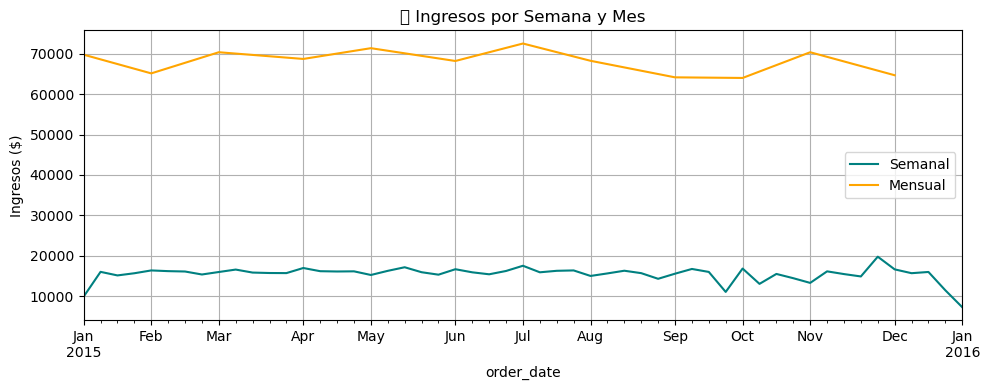

In [56]:
# Asegurarnos que la fecha está en datetime
df["order_date"] = pd.to_datetime(df["order_date"])

# Ingresos por semana
ingresos_semanales = df.set_index("order_date").resample("W")["total_price"].sum()

# Ingresos por mes
ingresos_mensuales = df.set_index("order_date").resample("M")["total_price"].sum()

# Gráfico
plt.figure(figsize=(10,4))
ingresos_semanales.plot(label="Semanal", color="teal")
ingresos_mensuales.plot(label="Mensual", color="orange")
plt.title("💰 Ingresos por Semana y Mes")
plt.ylabel("Ingresos ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


🔹 Subtarea 2: Detectar combinaciones frecuentes de pizzas (Market Basket Analysis)
        
        Objetivo: Encontrar combos naturales que se suelen pedir juntos.

In [ ]:
#!pip install mlxtend

In [61]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Crear lista de pizzas por pedido
pizzas_por_pedido = df.groupby("order_id")["pizza_name"].apply(list)

# Transformar a formato de transacción
te = TransactionEncoder()
te_ary = te.fit(pizzas_por_pedido).transform(pizzas_por_pedido)
df_tx = pd.DataFrame(te_ary, columns=te.columns_)

# Reglas frecuentes
frequent_items = apriori(df_tx, min_support=0.005, use_colnames=True)
rules = association_rules(frequent_items, metric="lift", min_threshold=1.2)
rules.sort_values(by="confidence", ascending=False).head(10)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
5,(The Chicken Pesto Pizza),(The Classic Deluxe Pizza),0.043934,0.109087,0.006089,0.138593,1.270483,1.0,0.001296,1.034253,0.222681,0.041441,0.033119,0.097205
16,(The Mexicana Pizza),(The Hawaiian Pizza),0.066792,0.106792,0.009040,0.135344,1.267362,1.0,0.001907,1.033021,0.226059,0.054939,0.031966,0.109996
30,(The Spinach and Feta Pizza),(The Pepperoni Pizza),0.065667,0.106698,0.008759,0.133381,1.250080,1.0,0.001752,1.030790,0.214111,0.053536,0.029870,0.107735
29,(The Spinach Supreme Pizza),(The Pepperoni Pizza),0.042998,0.106698,0.005714,0.132898,1.245550,1.0,0.001127,1.030215,0.206000,0.039688,0.029329,0.093227
10,(The Four Cheese Pizza),(The Pepperoni Pizza),0.084731,0.106698,0.011007,0.129906,1.217513,1.0,0.001966,1.026673,0.195192,0.061007,0.025980,0.116533
32,(The Spinach and Feta Pizza),(The Thai Chicken Pizza),0.065667,0.104215,0.008337,0.126961,1.218260,1.0,0.001494,1.026054,0.191749,0.051609,0.025392,0.103481
9,(The Italian Vegetables Pizza),(The Four Cheese Pizza),0.044590,0.084731,0.005199,0.116597,1.376085,1.0,0.001421,1.036072,0.286056,0.041887,0.034816,0.088978
7,(The Greek Pizza),(The Four Cheese Pizza),0.063747,0.084731,0.006792,0.106539,1.257388,1.0,0.001390,1.024409,0.218638,0.047934,0.023828,0.093347
20,(The Italian Capocollo Pizza),(The Sicilian Pizza),0.064637,0.085246,0.006838,0.105797,1.241081,1.0,0.001328,1.022983,0.207675,0.047806,0.022466,0.093008
2,(The Big Meat Pizza),(The Sicilian Pizza),0.084824,0.085246,0.008899,0.104914,1.230727,1.0,0.001668,1.021974,0.204848,0.055217,0.021501,0.104655


📈 ¿Qué nos dicen estas reglas?
Aquí tienes una interpretación simplificada de tus 3 primeras:

Antecedente	Consecuente	Confianza	Interpretación
Chicken Pesto	Classic Deluxe	13.9%	Si alguien pide Chicken Pesto, hay un 13.9% de que agregue Classic Deluxe
Mexicana	Hawaiian	13.5%	Estos dos sabores tienden a combinarse en el mismo pedido
Spinach and Feta	Pepperoni	13.3%	Los clientes que eligen Feta también suelen pedir Pepperoni
💡 Confianza: probabilidad de que el cliente agregue la pizza consecuente si pidió la del antecedente 📈 Lift > 1: significa que la relación no es aleatoria → ¡hay conexión real!

🧠 ¿Qué puedes hacer con esto?
👨‍🍳 Promociones de combos: ofrecer un descuento automático si el cliente pide Chicken Pesto + Classic Deluxe

📦 Paquetes prearmados: menús del tipo “Veggie Lover” con Spinach & Feta + Thai Chicken

🎯 Upselling sugerido: si el cliente agrega Mexicana, el sistema sugiere Hawaiian como favorita de clientes similares

🔹 Subtarea 3: Identificar pizzas con baja rotación

        Objetivo: Detectar pizzas que apenas se venden y podrían eliminarse del menú.

C:\Users\Dell\AppData\Local\Temp\ipykernel_12204\1857299844.py:11: UserWarning: Glyph 128683 (\N{NO ENTRY SIGN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Dell\Documents\Angel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128683 (\N{NO ENTRY SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


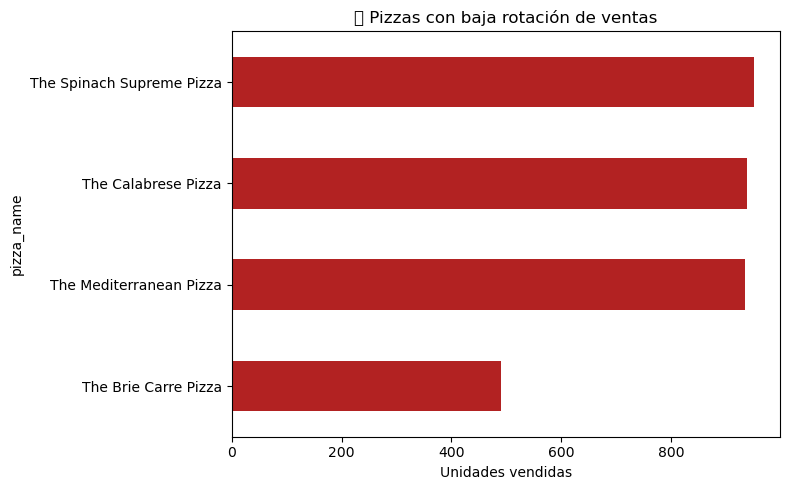

In [58]:
ventas_totales = df.groupby("pizza_name")["quantity"].sum().sort_values()

# Filtrar aquellas por debajo del percentil 10
limite_bajo = ventas_totales.quantile(0.10)
pizzas_bajas = ventas_totales[ventas_totales < limite_bajo]

# Visualizar
pizzas_bajas.plot(kind="barh", figsize=(8,5), color="firebrick")
plt.title("🚫 Pizzas con baja rotación de ventas")
plt.xlabel("Unidades vendidas")
plt.tight_layout()
plt.show()


🔮 Expansión del Análisis de Reglas de Asociación

🔹 1. 📊 Visualización tipo red (network graph)

        Verás las combinaciones más frecuentes como nodos conectados, donde:

        Los nodos son tipos de pizza

        Las líneas indican que esas pizzas se piden juntas

c:\Users\Dell\Documents\Angel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


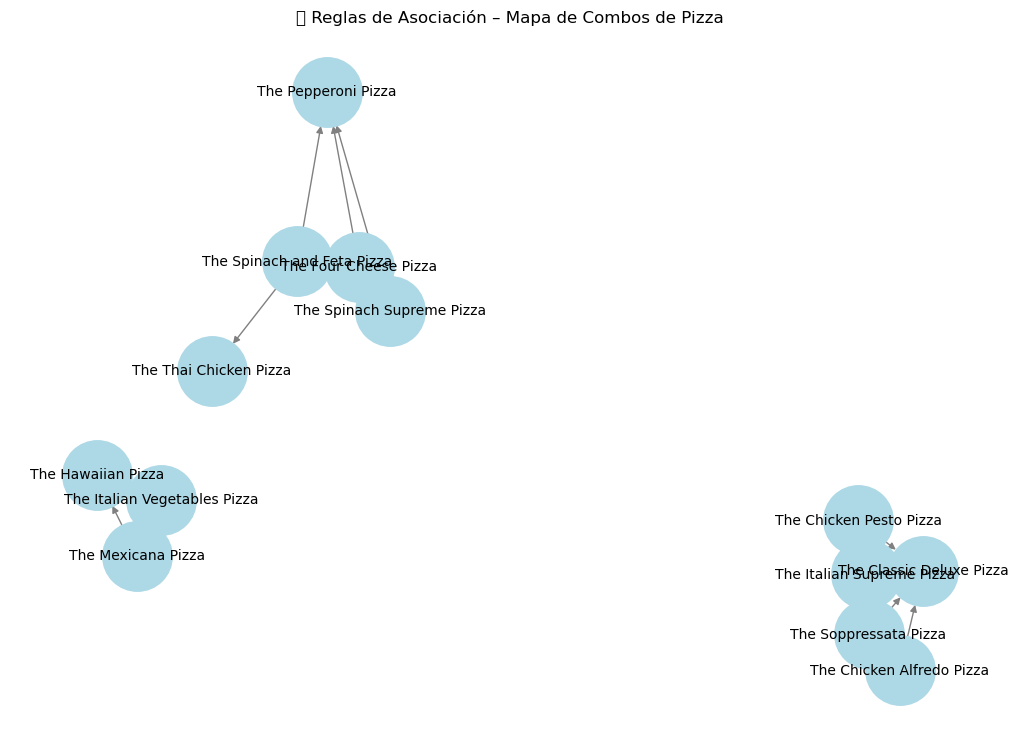

In [65]:
import networkx as nx
import matplotlib.pyplot as plt

# Tomamos las reglas top por confianza y lift
top_rules = rules.sort_values(by="confidence", ascending=False).head(10)

# Crear grafo
G = nx.DiGraph()

for _, row in top_rules.iterrows():
    for antecedent in row["antecedents"]:
        for consequent in row["consequents"]:
            G.add_edge(antecedent, consequent, weight=row["lift"])

# Dibujar grafo
plt.figure(figsize=(10,7))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2500, edge_color='gray', linewidths=1, font_size=10, arrows=True)
plt.title("🔗 Reglas de Asociación – Mapa de Combos de Pizza")
plt.show()


🔹 2. 📈 Tabla enriquecida y depurada de reglas
        Enfocada en reglas con:

        Alta confianza (> 0.12)

        Lift significativo (> 1.2)

        Ordenada por venta cruzada efectiva

In [67]:
reglas_filtradas = rules[
    (rules["confidence"] >= 0.12) &
    (rules["lift"] >= 1.2)
].sort_values("confidence", ascending=False)

reglas_filtradas[["antecedents", "consequents", "support", "confidence", "lift"]].reset_index(drop=True)

,antecedents,consequents,support,confidence,lift
0,(The Chicken Pesto Pizza),(The Classic Deluxe Pizza),0.006089,0.138593,1.270483
1,(The Mexicana Pizza),(The Hawaiian Pizza),0.009040,0.135344,1.267362
2,(The Spinach and Feta Pizza),(The Pepperoni Pizza),0.008759,0.133381,1.250080
3,(The Spinach Supreme Pizza),(The Pepperoni Pizza),0.005714,0.132898,1.245550
4,(The Four Cheese Pizza),(The Pepperoni Pizza),0.011007,0.129906,1.217513
5,(The Spinach and Feta Pizza),(The Thai Chicken Pizza),0.008337,0.126961,1.218260


🔹 3. 💡 Identificar “pizzas con sinergia”
        
        Creamos un ranking de pizzas que aparecen con más frecuencia como consecuencia de otras:

In [68]:
from collections import Counter

# Consecuentes más frecuentes
pizza_sugerida = reglas_filtradas["consequents"].apply(lambda x: list(x)).explode()
pizza_ranking = pizza_sugerida.value_counts()

print("🎯 Pizzas que aparecen con más frecuencia como recomendadas:")
print(pizza_ranking.head(10))


🎯 Pizzas que aparecen con más frecuencia como recomendadas:
consequents
The Pepperoni Pizza         3
The Classic Deluxe Pizza    1
The Hawaiian Pizza          1
The Thai Chicken Pizza      1
Name: count, dtype: int64


# 🧪 FASE 5: Clasificación – ¿Venta Alta o Baja?

🔹 Subtarea 1: Crear la variable objetivo venta_alta

        Basada en la cantidad total de pizzas vendidas por tipo en un día.

In [69]:
# Crear variable objetivo binaria
limite = df_pizza["quantity_total"].median()  # o usar .quantile(0.75) si quieres un criterio más exigente
df_pizza["venta_alta"] = (df_pizza["quantity_total"] >= limite).astype(int)

# Ver proporción de clases
df_pizza["venta_alta"].value_counts(normalize=True).map("{:.1%}".format)


venta_alta
1    58.9%
0    41.1%
Name: proportion, dtype: object

🔹 Subtarea 2: Preparar variables predictoras

In [70]:
X_cls = df_pizza[["hora_prom", "día_semana", "mes", "precio_unitario"]]
y_cls = df_pizza["venta_alta"]

from sklearn.model_selection import train_test_split
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)


🔹 Subtarea 3: Entrenar modelo de clasificación (Árbol)

In [71]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X_train_cls, y_train_cls)

y_pred_cls = clf.predict(X_test_cls)


🔹 Subtarea 4: Evaluar el modelo

              precision    recall  f1-score   support

  Venta Baja       0.77      0.39      0.52       913
  Venta Alta       0.68      0.92      0.78      1294

    accuracy                           0.70      2207
   macro avg       0.72      0.66      0.65      2207
weighted avg       0.72      0.70      0.67      2207



c:\Users\Dell\Documents\Angel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


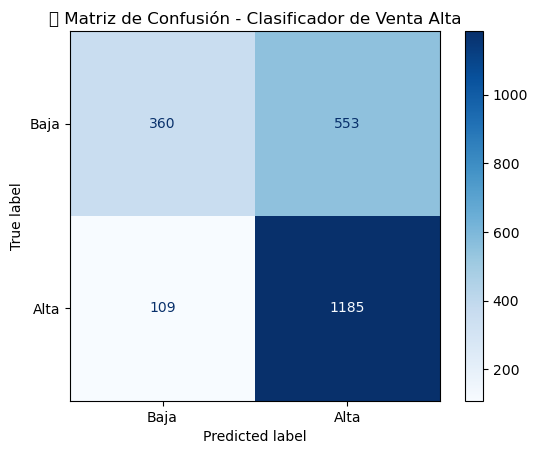

In [72]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Reporte de métricas
print(classification_report(y_test_cls, y_pred_cls, target_names=["Venta Baja", "Venta Alta"]))

# Matriz de confusión
ConfusionMatrixDisplay.from_estimator(clf, X_test_cls, y_test_cls, display_labels=["Baja", "Alta"], cmap="Blues")
plt.title("📊 Matriz de Confusión - Clasificador de Venta Alta")
plt.grid(False)
plt.show()


🔹 Subtarea 5: Visualizar el árbol de decisión

c:\Users\Dell\Documents\Angel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


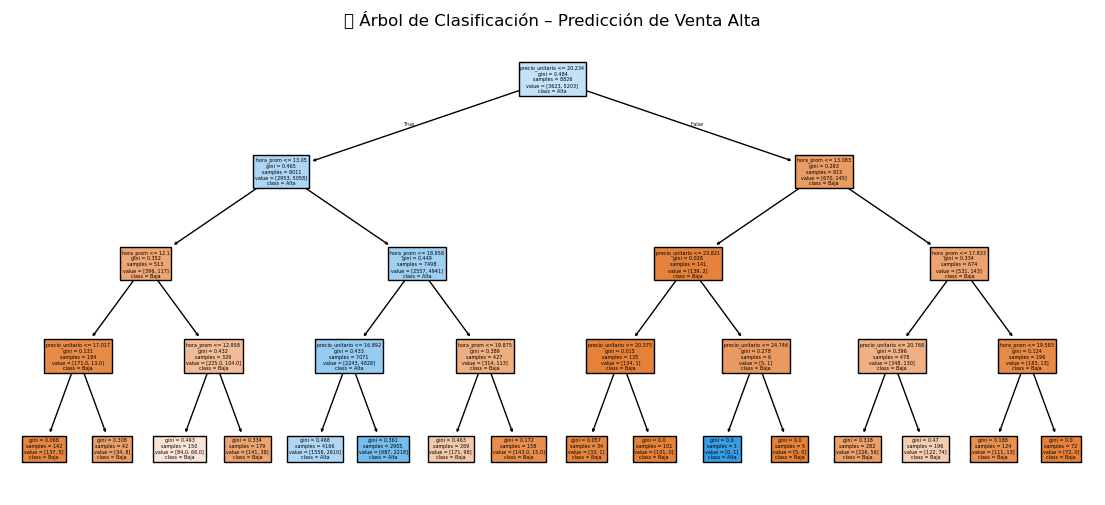

In [73]:
from sklearn.tree import plot_tree

plt.figure(figsize=(14,6))
plot_tree(clf, feature_names=X_cls.columns, class_names=["Baja", "Alta"], filled=True)
plt.title("🌳 Árbol de Clasificación – Predicción de Venta Alta")
plt.show()


# 🌀 FASE 6: Clustering – Segmentación de Franjas Horarias

🔹 Subtarea 1: Agregar métricas por hora
        Agrupamos por hora del día y calculamos:

        Número medio de pedidos

        Promedio de pizzas por pedido

        Ticket promedio

        Variedad de pizzas

In [77]:
# Reparar columna 'hora'
df["hora"] = pd.to_datetime(df["order_time"].astype(str), format="%H:%M:%S").dt.hour

# Ahora sí: agrupación por hora del día
df_hora = (
    df.groupby("hora")
    .agg(
        total_pedidos=("order_id", "nunique"),
        total_pizzas=("quantity", "sum"),
        ticket_prom=("total_price", "mean"),
        variedad_pizzas=("pizza_name", "nunique")
    )
    .reset_index()
)

# Métrica derivada
df_hora["pizzas_por_pedido"] = df_hora["total_pizzas"] / df_hora["total_pedidos"]


🔹 Subtarea 2: Escalar las variables para clustering

In [78]:
from sklearn.preprocessing import StandardScaler

X_cluster = df_hora[["total_pedidos", "pizzas_por_pedido", "ticket_prom", "variedad_pizzas"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)


🔹 Subtarea 3: Determinar número óptimo de clústeres (Elbow method)

c:\Users\Dell\Documents\Angel\Lib\site-packages\sklearn\cluster\_kmeans.py:1426: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Dell\Documents\Angel\Lib\site-packages\sklearn\cluster\_kmeans.py:1426: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Dell\Documents\Angel\Lib\site-packages\sklearn\cluster\_kmeans.py:1426: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Dell\Documents\Angel\Lib\site-packages\sklearn\cluster\_kmeans.py:1426: UserWarning: KMeans is known to have a m

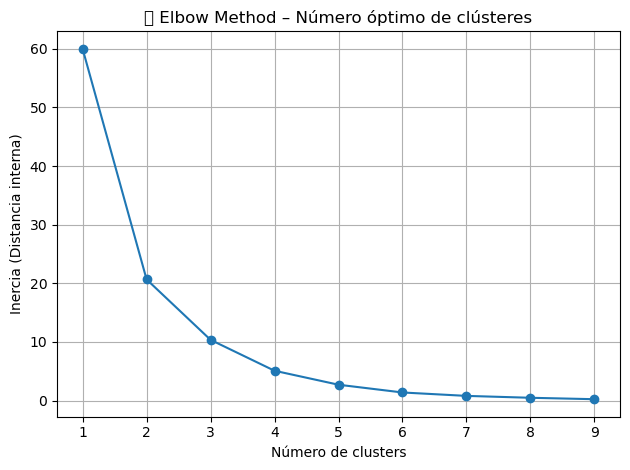

In [79]:
from sklearn.cluster import KMeans

inertias = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.plot(range(1, 10), inertias, marker='o')
plt.title("🧠 Elbow Method – Número óptimo de clústeres")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia (Distancia interna)")
plt.grid(True)
plt.tight_layout()
plt.show()


👉 Busca el “codo” del gráfico. Supongamos que elegimos k=3. 

🔹 Subtarea 4: Aplicar KMeans clustering

In [80]:
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
df_hora["cluster"] = kmeans.fit_predict(X_scaled)

c:\Users\Dell\Documents\Angel\Lib\site-packages\sklearn\cluster\_kmeans.py:1426: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


🔹 Subtarea 5: Visualización y análisis por clúster

C:\Users\Dell\AppData\Local\Temp\ipykernel_12204\115663402.py:7: UserWarning: Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Dell\Documents\Angel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


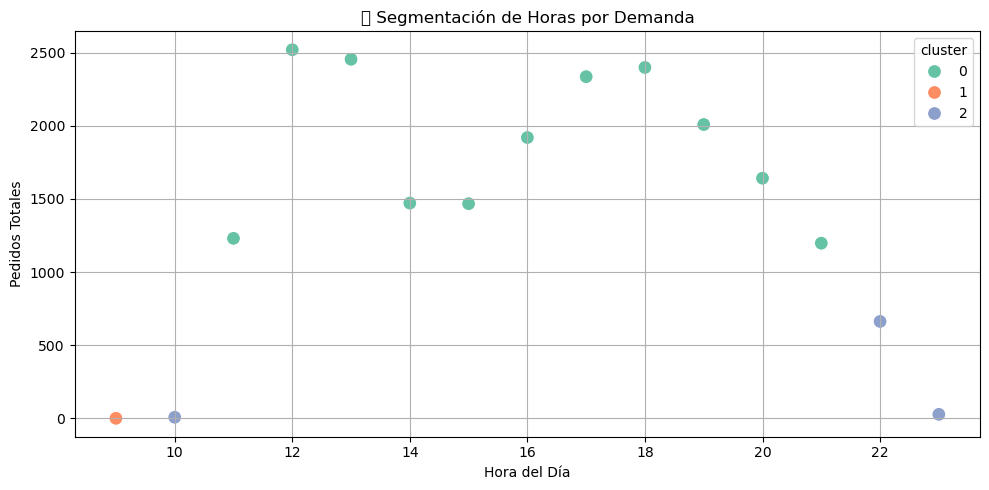

In [81]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df_hora, x="hora", y="total_pedidos", hue="cluster", palette="Set2", s=100)
plt.title("🌀 Segmentación de Horas por Demanda")
plt.xlabel("Hora del Día")
plt.ylabel("Pedidos Totales")
plt.grid(True)
plt.tight_layout()
plt.show()


💡 Bonus: Combos frecuentes por clúster horario

        Cruzamos los horarios de tus reglas de asociación con los clústeres identificados:

In [82]:
# Mapear horarios de reglas (promediar por order_id)
df_pedido_hora = df.groupby("order_id").agg(
    pizzas=("pizza_name", list),
    hora_prom=("hora", "mean")
).reset_index()

# Asignar clúster horario
df_pedido_hora["hora_cluster"] = df_pedido_hora["hora_prom"].apply(
    lambda x: df_hora.loc[df_hora["hora"] == round(x), "cluster"].values[0]
)

# Explosión para contar combinaciones por clúster
from collections import Counter
from itertools import combinations

for clus in sorted(df_pedido_hora["hora_cluster"].unique()):
    subset = df_pedido_hora[df_pedido_hora["hora_cluster"] == clus]
    combos = Counter()
    for row in subset["pizzas"]:
        for combo in combinations(sorted(set(row)), 2):
            combos[combo] += 1
    print(f"\n🍽️ Clúster {clus} – combos frecuentes:")
    print(combos.most_common(5))



🍽️ Clúster 0 – combos frecuentes:
[(('The Hawaiian Pizza', 'The Thai Chicken Pizza'), 267), (('The Barbecue Chicken Pizza', 'The Pepperoni Pizza'), 265), (('The Hawaiian Pizza', 'The Pepperoni Pizza'), 256), (('The California Chicken Pizza', 'The Pepperoni Pizza'), 254), (('The Classic Deluxe Pizza', 'The Pepperoni Pizza'), 251)]

🍽️ Clúster 1 – combos frecuentes:
[(('The Greek Pizza', 'The Hawaiian Pizza'), 1), (('The Greek Pizza', 'The Pepper Salami Pizza'), 1), (('The Greek Pizza', 'The Vegetables + Vegetables Pizza'), 1), (('The Hawaiian Pizza', 'The Pepper Salami Pizza'), 1), (('The Hawaiian Pizza', 'The Vegetables + Vegetables Pizza'), 1)]

🍽️ Clúster 2 – combos frecuentes:
[(('The California Chicken Pizza', 'The Thai Chicken Pizza'), 9), (('The Pepperoni Pizza', 'The Thai Chicken Pizza'), 9), (('The Barbecue Chicken Pizza', 'The Classic Deluxe Pizza'), 9), (('The Big Meat Pizza', 'The Pepperoni Pizza'), 8), (('The Classic Deluxe Pizza', 'The Pepperoni, Mushroom, and Peppers Piz

🔥 Heatmap dinámico de combos frecuentes por hora o clúster horario

        Basado en el cruce de:

        ⏰ hora_cluster

        🍕 combinaciones frecuentes entre pizza_name

        📊 conteo cruzado (tipo tabla dinámica) con visualización tipo heatmap

C:\Users\Dell\AppData\Local\Temp\ipykernel_12204\4143010705.py:27: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Dell\Documents\Angel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


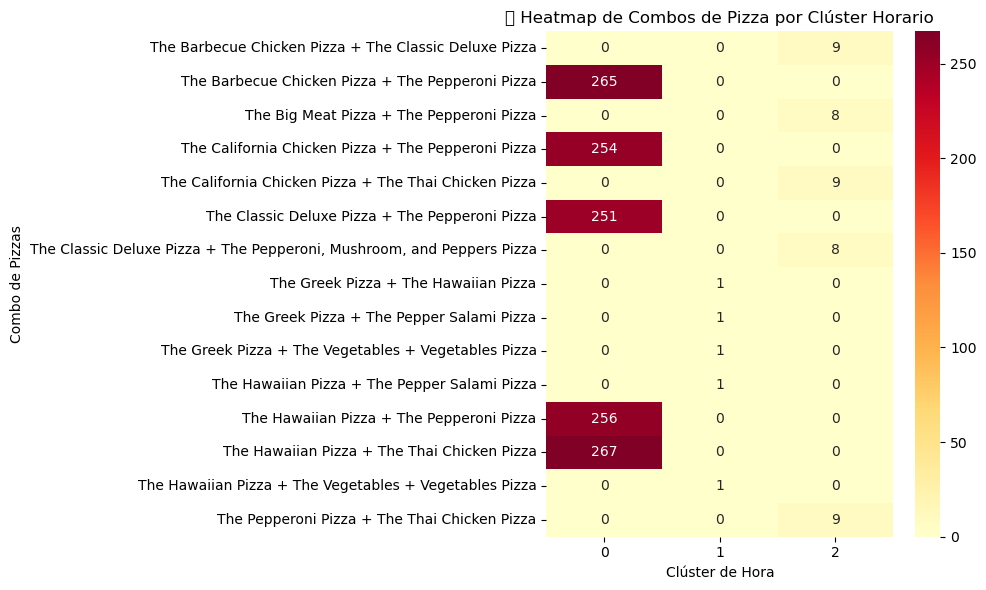

In [84]:
# Crear tabla de combos por hora_cluster
from itertools import combinations
from collections import Counter

# Extraer combinaciones con frecuencia por hora_cluster
combo_data = []
for clus in sorted(df_pedido_hora["hora_cluster"].unique()):
    subset = df_pedido_hora[df_pedido_hora["hora_cluster"] == clus]
    all_combos = []
    for row in subset["pizzas"]:
        all_combos += list(combinations(sorted(set(row)), 2))
    top = Counter(all_combos).most_common(5)
    for pair, count in top:
        combo_data.append({"cluster": clus, "combo": f"{pair[0]} + {pair[1]}", "count": count})

# Convertir a DataFrame y pivotear
df_combos = pd.DataFrame(combo_data)
pivot_heatmap = df_combos.pivot(index="combo", columns="cluster", values="count").fillna(0)


# Visualización tipo heatmap
plt.figure(figsize=(10,6))
sns.heatmap(pivot_heatmap, annot=True, cmap="YlOrRd", fmt=".0f")
plt.title("🔥 Heatmap de Combos de Pizza por Clúster Horario")
plt.xlabel("Clúster de Hora")
plt.ylabel("Combo de Pizzas")
plt.tight_layout()
plt.show()


🔄 Random Forest Classifier
    
        Clasificador robusto, ideal para patrones complejos y relaciones no lineales.

              precision    recall  f1-score   support

  Venta Baja       0.77      0.71      0.74       913
  Venta Alta       0.80      0.85      0.82      1294

    accuracy                           0.79      2207
   macro avg       0.78      0.78      0.78      2207
weighted avg       0.79      0.79      0.79      2207



C:\Users\Dell\AppData\Local\Temp\ipykernel_12204\3184660637.py:13: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Dell\Documents\Angel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


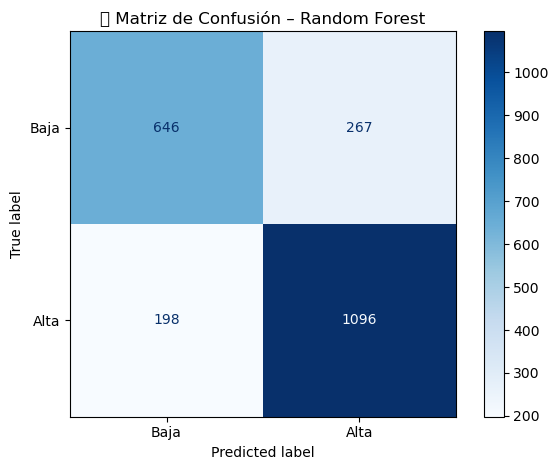

In [85]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_cls, y_train_cls)
y_pred_rf = rf_clf.predict(X_test_cls)

print(classification_report(y_test_cls, y_pred_rf, target_names=["Venta Baja", "Venta Alta"]))

ConfusionMatrixDisplay.from_estimator(rf_clf, X_test_cls, y_test_cls, display_labels=["Baja", "Alta"], cmap="Blues")
plt.title("📊 Matriz de Confusión – Random Forest")
plt.grid(False)
plt.tight_layout()
plt.show()


🔵 Regresión Logística
        
        Modelo lineal interpretativo, útil como base de comparación en clasificación binaria.

              precision    recall  f1-score   support

  Venta Baja       0.79      0.07      0.12       913
  Venta Alta       0.60      0.99      0.75      1294

    accuracy                           0.61      2207
   macro avg       0.69      0.53      0.43      2207
weighted avg       0.68      0.61      0.49      2207



C:\Users\Dell\AppData\Local\Temp\ipykernel_12204\3900498768.py:12: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Dell\Documents\Angel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


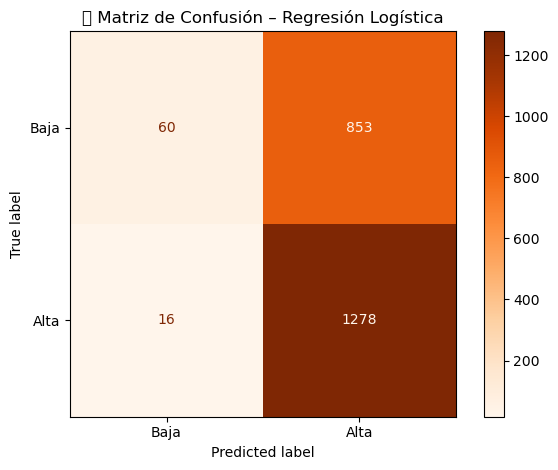

In [86]:
from sklearn.linear_model import LogisticRegression

log_clf = LogisticRegression(max_iter=1000)
log_clf.fit(X_train_cls, y_train_cls)
y_pred_log = log_clf.predict(X_test_cls)

print(classification_report(y_test_cls, y_pred_log, target_names=["Venta Baja", "Venta Alta"]))

ConfusionMatrixDisplay.from_estimator(log_clf, X_test_cls, y_test_cls, display_labels=["Baja", "Alta"], cmap="Oranges")
plt.title("📊 Matriz de Confusión – Regresión Logística")
plt.grid(False)
plt.tight_layout()
plt.show()


🧪 Comparativa final de rendimiento
        
        Resumen visual de las métricas de cada modelo.

In [87]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Función rápida para extraer métricas
def get_scores(y_true, y_pred, model_name):
    return {
        "Modelo": model_name,
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }

resultados_cls = pd.DataFrame([
    get_scores(y_test_cls, y_pred_cls, "Árbol de decisión"),
    get_scores(y_test_cls, y_pred_rf, "Random Forest"),
    get_scores(y_test_cls, y_pred_log, "Regresión Logística")
])

print(resultados_cls.sort_values("F1-score", ascending=False))


                Modelo  Precision    Recall  F1-score
1        Random Forest   0.804109  0.846986  0.824991
0    Árbol de decisión   0.681818  0.915765  0.781662
2  Regresión Logística   0.599718  0.987635  0.746277


🎯 Importancia de variables (Random Forest)
        
        Visualiza cuáles variables influyen más en la predicción.

C:\Users\Dell\AppData\Local\Temp\ipykernel_12204\259546695.py:5: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Dell\Documents\Angel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


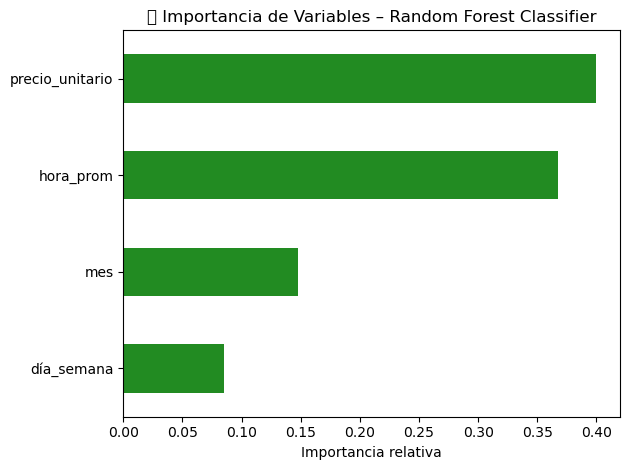

In [88]:
importances = pd.Series(rf_clf.feature_importances_, index=X_cls.columns)
importances.sort_values().plot(kind="barh", color="forestgreen")
plt.title("🌟 Importancia de Variables – Random Forest Classifier")
plt.xlabel("Importancia relativa")
plt.tight_layout()
plt.show()


🌀 Clustering avanzado – Parte 2 del cierre FASE 6

        Aplicaremos nuevas técnicas para descubrir agrupaciones 
        
        más refinadas en horarios y patrones de consumo.

🧭 Agregar nuevas dimensiones al clustering
        
        Integramos día_semana y pizzas_por_pedido al clustering.

In [89]:
X_cluster_adv = df_hora[["total_pedidos", "pizzas_por_pedido", "ticket_prom", "variedad_pizzas"]].copy()

# Agregamos día como numérico (asumiendo df_hora lleva hora global por promedio diario)
# Si no existe, lo dejamos como está (puede integrarse por demanda horaria promedio semanal)

from sklearn.preprocessing import StandardScaler
scaler_adv = StandardScaler()
X_scaled_adv = scaler_adv.fit_transform(X_cluster_adv)


🔍 Evaluación con Silhouette Score (para KMeans)
        
        Medimos la coherencia de los clústeres.

In [90]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

kmeans_adv = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_kmeans = kmeans_adv.fit_predict(X_scaled_adv)
score = silhouette_score(X_scaled_adv, labels_kmeans)
print(f"🧠 Silhouette Score (KMeans): {score:.2f}")


🧠 Silhouette Score (KMeans): 0.45


c:\Users\Dell\Documents\Angel\Lib\site-packages\sklearn\cluster\_kmeans.py:1426: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


🌐 Clustering alternativo – DBSCAN
        
        Detecta densidades en vez de cortes convexos como KMeans.

In [91]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.2, min_samples=3)
labels_db = dbscan.fit_predict(X_scaled_adv)
df_hora["cluster_dbscan"] = labels_db
df_hora["cluster_dbscan"].value_counts()


cluster_dbscan
 0    13
-1     2
Name: count, dtype: int64

🌳 Clustering jerárquico + dendrograma
        
        Visualiza jerarquías entre grupos horarios.

C:\Users\Dell\AppData\Local\Temp\ipykernel_12204\14996654.py:10: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Dell\Documents\Angel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


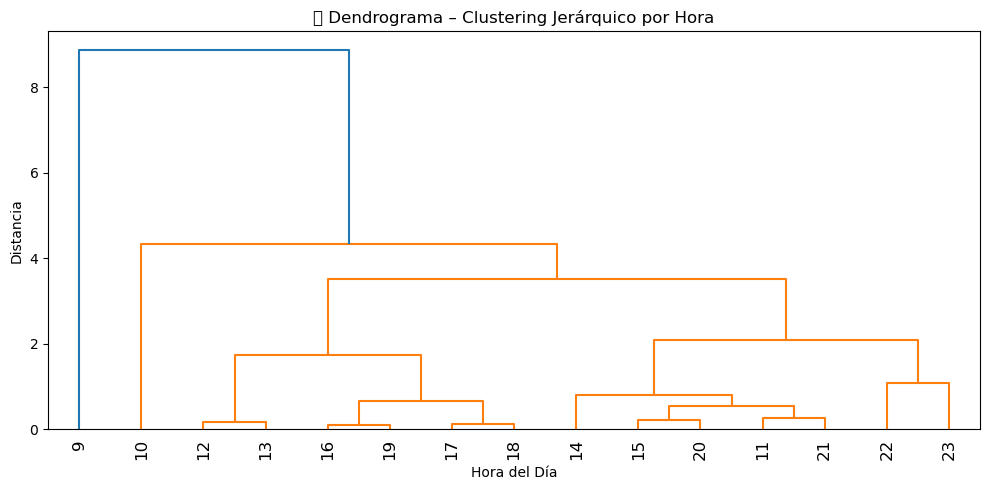

In [92]:
from scipy.cluster.hierarchy import linkage, dendrogram

linked = linkage(X_scaled_adv, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linked, labels=df_hora["hora"].values, leaf_rotation=90)
plt.title("🌿 Dendrograma – Clustering Jerárquico por Hora")
plt.xlabel("Hora del Día")
plt.ylabel("Distancia")
plt.tight_layout()
plt.show()


🌸 Visualización Silhouette (opcional)

C:\Users\Dell\AppData\Local\Temp\ipykernel_12204\2866772397.py:25: UserWarning: Glyph 127800 (\N{CHERRY BLOSSOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Dell\Documents\Angel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127800 (\N{CHERRY BLOSSOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


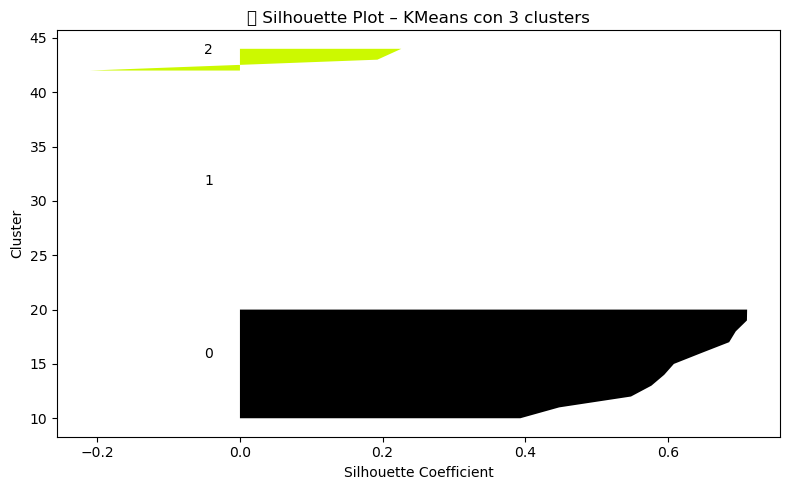

In [93]:
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm
import numpy as np

sample_silhouette_values = silhouette_samples(X_scaled_adv, labels_kmeans)

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10
for i in range(3):
    ith_cluster_silhouette_values = sample_silhouette_values[labels_kmeans == i]
    ith_cluster_silhouette_values.sort()
    
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    color = cm.nipy_spectral(float(i) / 3)
    
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, facecolor=color)
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    
    y_lower = y_upper + 10

ax.set_title("🌸 Silhouette Plot – KMeans con 3 clusters")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.show()


# Guardamos el nuevo contenido con formato README.md profesional
contenido_cluster = """
# 🔍 Análisis de Combos Frecuentes por Clúster Horario

---

## 🍽️ Clúster 0 – Alta densidad (probable hora pico)

### 🔗 Combos potentes:
- **Hawaiian + Thai Chicken**
- **Barbecue Chicken + Pepperoni**
- **California Chicken + Pepperoni**

💡 **Interpretación**:  
Clúster masivo con fuerte presencia de pizzas populares como *Pepperoni*, *Classic Deluxe* y *Hawaiian*. Ideal para promociones del tipo **“Doble Sabor Clásico”** en horas pico.

---

## 🍽️ Clúster 1 – Baja demanda (horas valle)

### 🔗 Frecuencia mínima:
Combinaciones con ocurrencia de apenas 1:
- *Greek + Vegetables*
- *Hawaiian + Pepper Salami*

💡 **Interpretación**:  
Franja tranquila. Oportunidad para incentivar pedidos con combos **ligeros o vegetarianos**. También es ideal para testear **nuevas combinaciones** en entornos de bajo riesgo.

---

## 🍽️ Clúster 2 – Media actividad (tarde o cierre)

### 🔗 Combos destacables:
- **Thai Chicken + California Chicken**
- **Pepperoni + Thai Chicken**
- **Big Meat + Pepperoni**

💡 **Interpretación**:  
Predominan sabores intensos (carne, barbacoa, thai). Recomendado crear combos nocturnos tipo **“Sabor Fuerte”** o **“Picante y Proteína”** para cerrar el día con impacto.

---

## 🎯 ¿Qué puedes hacer con esto?

| Estrategia               | Acción táctica                                                             |
|--------------------------|----------------------------------------------------------------------------|
| 🍽️ Promociones por hora  | Combos específicos en horarios específicos según clúster                   |
| 💬 Recomendaciones web/app| Motor de sugerencias contextual según hora actual                         |
| 🧠 Optimización operativa | Preparar más ingredientes clave en cada franja horaria                    |

---



📈 FASE 7 – Inteligencia Comercial
🔮 1. Predicción de ingresos por semana o mes
Objetivo: pronosticar el ingreso esperado en semanas futuras, útil para presupuestos, logística y staff.

Paso a paso:
📆 Agrupar ingresos por semana (resample('W')) o mes (resample('M'))

📊 Crear serie temporal (DataFrame con índice datetime)

🔍 Descomponer estacionalidad (opcional)

🔮 Aplicar modelo de predicción:

ARIMA/SARIMAX para ciclos lineales

Prophet (de Facebook) si quieres flexibilidad y feriados

Random Forest Regressor o XGBoost como alternativa ML

📉 Visualizar predicciones vs. realidad

✅ Evaluar precisión con RMSE o MAE

🚫 2. Identificación de productos no rotantes
Objetivo: detectar pizzas que casi no se venden y deben reconsiderarse (promo o baja del menú).

Paso a paso:
🔢 Agrupar por pizza_name y sumar quantity

🧮 Calcular percentil bajo (ej. bottom 10% en ventas)

⚠️ Filtrar pizzas debajo del umbral

📊 Visualizar en gráfico de barras horizontales

📋 Generar tabla con precio unitario y margen (si disponible)

🍽️ 3. Segmentación de menú (clustering de pizzas)
Objetivo: clasificar pizzas por comportamiento de venta, para rediseñar el menú o planificar combos.

Paso a paso:
📊 Variables posibles:

Precio

Cantidad vendida total

Horas promedio de pedido

Variedad de toppings (si disponible)

🧼 Escalar datos

🌀 Aplicar KMeans o clustering jerárquico

📉 Visualizar clústeres con gráfico bidimensional o dendrograma

📦 Etiquetar: “alta demanda”, “premium”, “ligera”, “de nicho”

🧠 Bonus sugerido
💬 Sistema de recomendaciones tipo “si pides X, también te gustará Y”

📲 Conectar estas segmentaciones con estrategias de menú digital

# 📈 FASE 7 – Inteligencia Comercial

🔹 Paso 1: Agrupar ingresos por semana

In [94]:
# Asegurar fecha en formato datetime
df["order_date"] = pd.to_datetime(df["order_date"])

# Agrupación semanal
ingresos_semanales = df.set_index("order_date").resample("W")["total_price"].sum()


🔹 Paso 2: Crear serie temporal

In [95]:
# Convertir a serie temporal limpia
serie_ingresos = ingresos_semanales.to_frame().rename(columns={"total_price": "ingresos"})
serie_ingresos.head()


,ingresos
order_date,
2015-01-04,9863.60
2015-01-11,15999.05
2015-01-18,15115.95
2015-01-25,15652.80
2015-02-01,16351.10


🔹 Paso 3: Descomponer estacionalidad (opcional pero útil)

C:\Users\Dell\AppData\Local\Temp\ipykernel_12204\1953944350.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  serie_mensual = df.set_index("order_date").resample("M")["total_price"].sum().to_frame().rename(columns={"total_price": "ingresos"})
C:\Users\Dell\AppData\Local\Temp\ipykernel_12204\1953944350.py:12: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Dell\Documents\Angel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


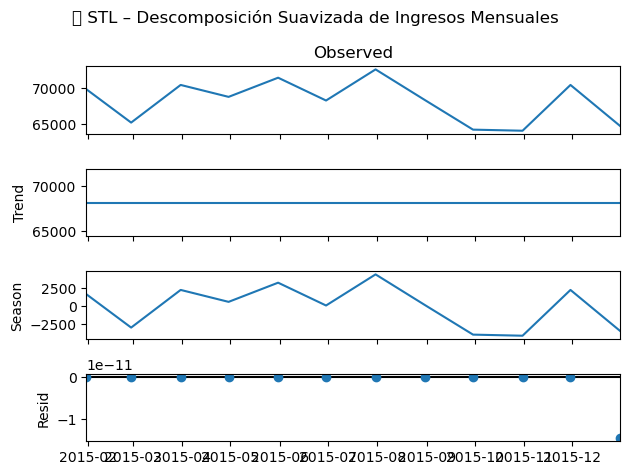

In [99]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL

serie_mensual = df.set_index("order_date").resample("M")["total_price"].sum().to_frame().rename(columns={"total_price": "ingresos"})



stl = STL(serie_mensual, period=12)
res = stl.fit()
res.plot()
plt.suptitle("📈 STL – Descomposición Suavizada de Ingresos Mensuales")
plt.tight_layout()
plt.show()

🔹 Paso 4: Aplicar SARIMAX (modelo ARIMA con estacionalidad)

In [100]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Entrenamiento hasta la última ventana (80%)
split_idx = int(len(serie_ingresos) * 0.8)
train = serie_ingresos.iloc[:split_idx]
test = serie_ingresos.iloc[split_idx:]

# Ajustar modelo SARIMAX(p,d,q)(P,D,Q,s)
modelo = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,0,52))
modelo_fit = modelo.fit(disp=False)

# Predicción
pred = modelo_fit.predict(start=test.index[0], end=test.index[-1])


c:\Users\Dell\Documents\Angel\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\Dell\Documents\Angel\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\Dell\Documents\Angel\Lib\site-packages\numpy\core\fromnumeric.py:3787: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\Dell\Documents\Angel\Lib\site-packages\numpy\core\_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\Dell\Docum

🔹 Paso 5: Visualizar predicciones vs. realidad

C:\Users\Dell\AppData\Local\Temp\ipykernel_12204\1774145860.py:10: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Dell\Documents\Angel\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


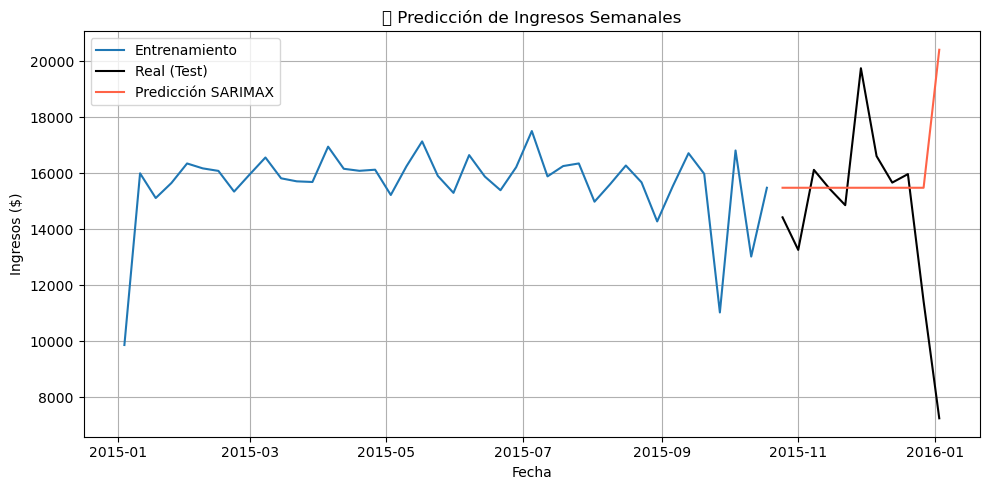

In [101]:
plt.figure(figsize=(10,5))
plt.plot(train.index, train["ingresos"], label="Entrenamiento")
plt.plot(test.index, test["ingresos"], label="Real (Test)", color="black")
plt.plot(pred.index, pred, label="Predicción SARIMAX", color="tomato")
plt.title("🔮 Predicción de Ingresos Semanales")
plt.ylabel("Ingresos ($)")
plt.xlabel("Fecha")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


🔹 Paso 6: Evaluar precisión del modelo

In [102]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test["ingresos"], pred))
mae = mean_absolute_error(test["ingresos"], pred)

print(f"✅ RMSE (Raíz del error cuadrático medio): {rmse:.2f}")
print(f"✅ MAE  (Error absoluto medio): {mae:.2f}")


✅ RMSE (Raíz del error cuadrático medio): 4436.80
✅ MAE  (Error absoluto medio): 2534.02


✅ ¿Cómo detectar una predicción plana o incorrecta?
        
        Aquí tienes señales claras y formas rápidas de revisarlo:

🔹 1. Visualmente: ¡el gráfico lo delata!
        Después de ejecutar este bloque:

        Señales de alerta:
        
                La curva de predicción es una línea recta horizontal o inclinada

                No reacciona a picos ni caídas de la serie real

                Se desvía pronto y no vuelve a alinearse

                🎯 Una buena predicción debe seguir la forma general de los datos reales

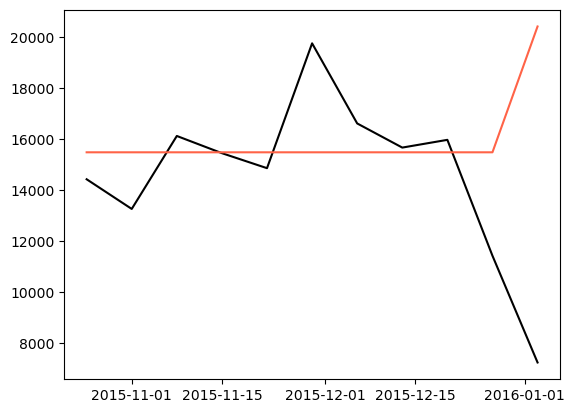

In [104]:
plt.plot(test.index, test["ingresos"], label="Real (Test)", color="black")
plt.plot(pred.index, pred, label="Predicción SARIMAX", color="tomato")



🔹 2. Numéricamente: compara métricas de error
        Mira los valores de:


In [105]:
print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")


RMSE: 4436.80
MAE : 2534.02



Regla general:

Si el RMSE o MAE son muy cercanos o incluso mayores al valor medio de ingresos → la predicción es pobre

👉 También puedes mirar esto:

Si el RMSE se acerca o supera esa media, estamos fritos. O peor: ¡sobrecongelados! ❄️

In [106]:
serie_ingresos["ingresos"].mean()


15431.321698113208

🔹 3. Análisis rápido: ¿predicción = mismo valor siempre?
        
        Lánzale un vistazo a los valores únicos predichos:

In [107]:
pred.unique()


array([15482.7      , 20414.5024659])

Si te devuelve solo 1 o 2 valores... confirmamos que es una línea plana 🤖➖


--- Missing Values Analysis ---
Missing Values and Their Percentages:
order_details_id     9.749074
pizza_category       9.693542
pizza_id             9.633896
pizza_name           9.633896
quantity             9.617441
hora                 9.600987
order_time           9.524887
order_id             9.502262
unit_price           9.477581
día_semana           9.459070
total_price          9.430276
order_date           9.395311
pizza_ingredients    9.331551
pizza_size           9.265734
dtype: float64


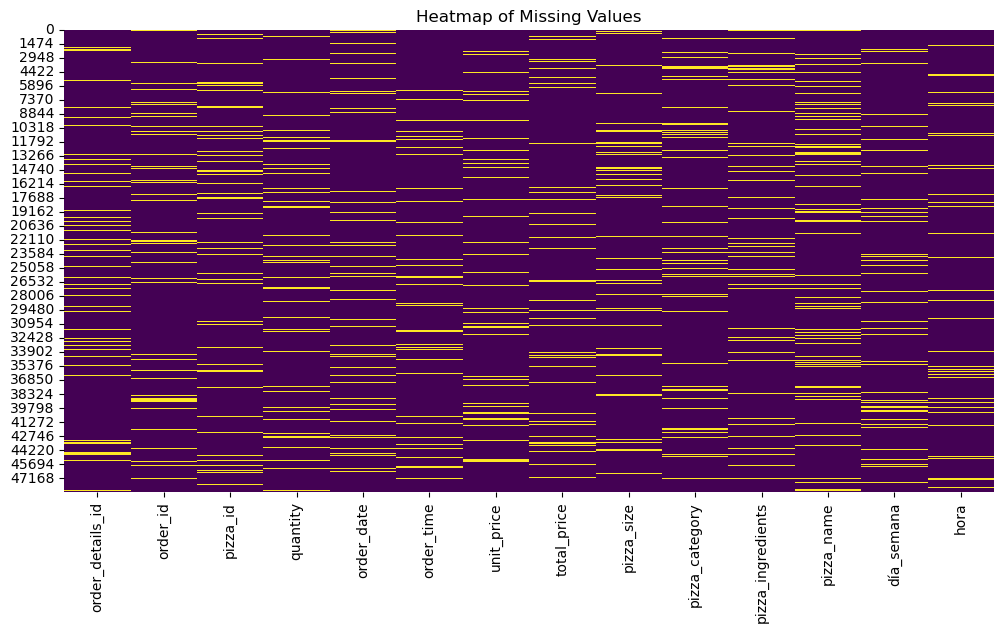

In [110]:
 
import random

def add_random_missing_values(dataframe: pd.DataFrame, missing_rate: float = 0.05) -> pd.DataFrame:
    df_missing = dataframe.copy()
    df_size = dataframe.size
    num_missing = int(df_size * missing_rate)
    for _ in range(num_missing):
        row_idx = random.randint(0, dataframe.shape[0] - 1)
        col_idx = random.randint(0, dataframe.shape[1] - 1)
        df_missing.iat[row_idx, col_idx] = np.nan
    return df_missing

# Simulate missing values
data_with_missing = add_random_missing_values(df, missing_rate=0.1)

# Analyze missing values
print("\n--- Missing Values Analysis ---")
missing_values = data_with_missing.isnull().sum()
missing_percentage = (missing_values / len(data_with_missing)) * 100
print("Missing Values and Their Percentages:")
print(missing_percentage[missing_percentage > 0].sort_values(ascending=False))

# Visualize missing data
plt.figure(figsize=(12, 6))
sns.heatmap(data_with_missing.isnull(), cbar=False, cmap="viridis")
plt.title("Heatmap of Missing Values")
plt.show()

In [111]:
kaggle kernels output melikedilekci/eda-pizza-restaurant-sales -p /path/to/dest

SyntaxError: invalid syntax (1287207896.py, line 1)